In [ ]:
!pip install emnist -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


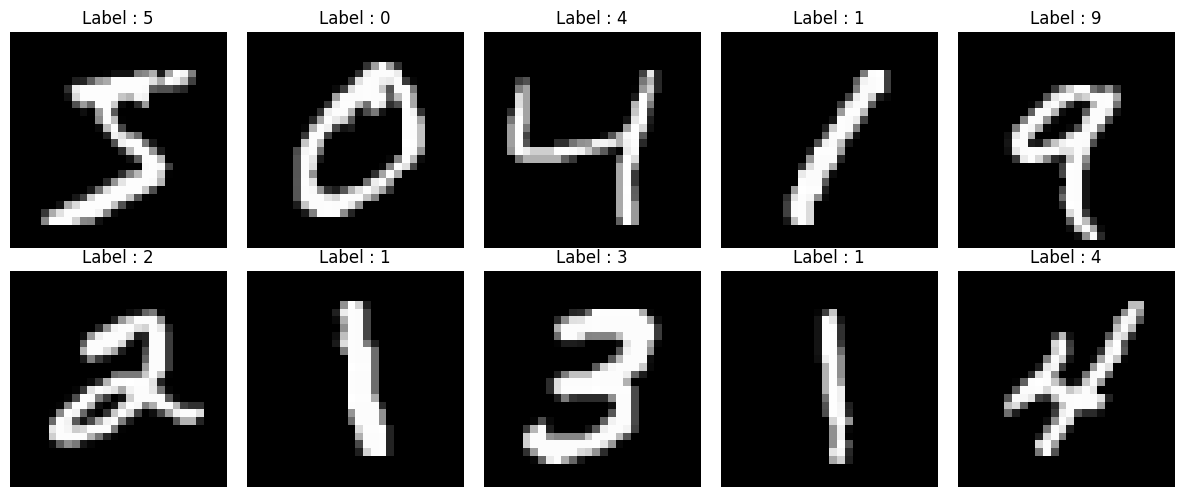

In [ ]:
plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title("Label : {}".format(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

print(y_train_cat.shape)

(60000, 10)


In [ ]:
mnist_model = Sequential()

mnist_model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(28,28,1)
    )
)

mnist_model.add(
    MaxPooling2D(pool_size=(2,2))
)

mnist_model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    )
)

mnist_model.add(
    MaxPooling2D(pool_size=(2,2))
)

mnist_model.add(Flatten())

mnist_model.add(
    Dense(
        128,
        activation="relu"
    )
)

mnist_model.add(
    Dropout(0.5)
)

mnist_model.add(
    Dense(
        10,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
mnist_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mnist_model.summary()

history_mnist = mnist_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8999 - loss: 0.3303 - val_accuracy: 0.9790 - val_loss: 0.0722
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9697 - loss: 0.1012 - val_accuracy: 0.9858 - val_loss: 0.0518
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9779 - loss: 0.0737 - val_accuracy: 0.9874 - val_loss: 0.0430
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9821 - loss: 0.0612 - val_accuracy: 0.9882 - val_loss: 0.0410
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9839 - loss: 0.0528 - val_accuracy: 0.9888 - val_loss: 0.0407
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9857 - loss: 0.0446 - val_accuracy: 0.9898 - val_loss: 0.0380
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9876 - loss: 0.0419 - val_accuracy: 0.9892 - val_loss: 0.0372
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9892 - loss: 0.0358 - val_accuracy:

In [ ]:
test_loss, test_accuracy = mnist_model.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0248

Test Loss     : 0.0248
Test Accuracy : 0.9920


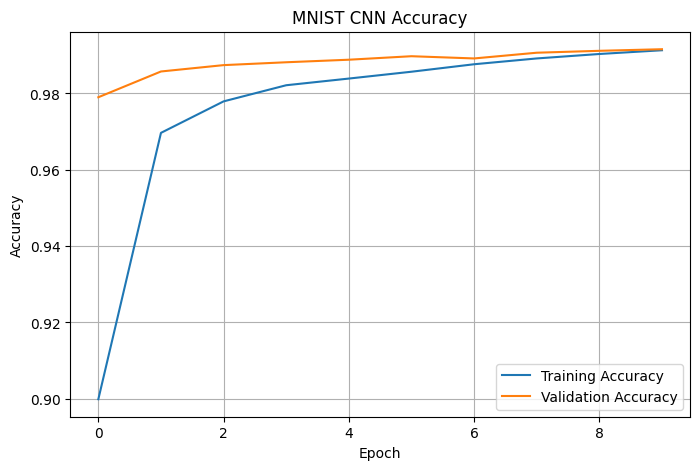

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_mnist.history['accuracy'], label='Training Accuracy')
plt.plot(history_mnist.history['val_accuracy'], label='Validation Accuracy')

plt.title("MNIST CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

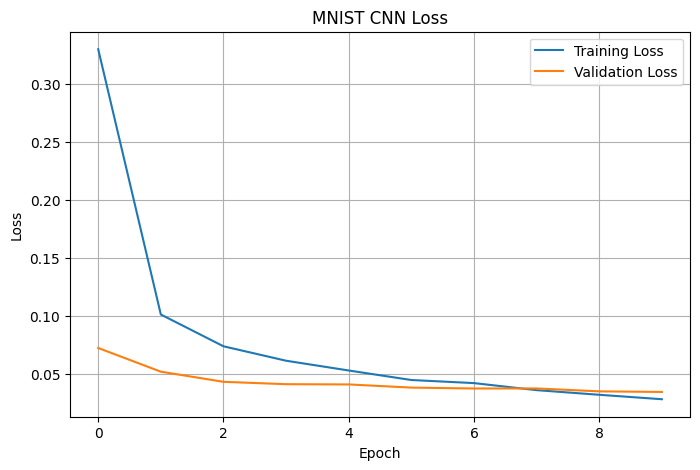

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_mnist.history['loss'], label='Training Loss')
plt.plot(history_mnist.history['val_loss'], label='Validation Loss')

plt.title("MNIST CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
predictions = mnist_model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print("Classification Report\n")

print(
    classification_report(
        y_test,
        predicted_labels
    )
)

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      1.00      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



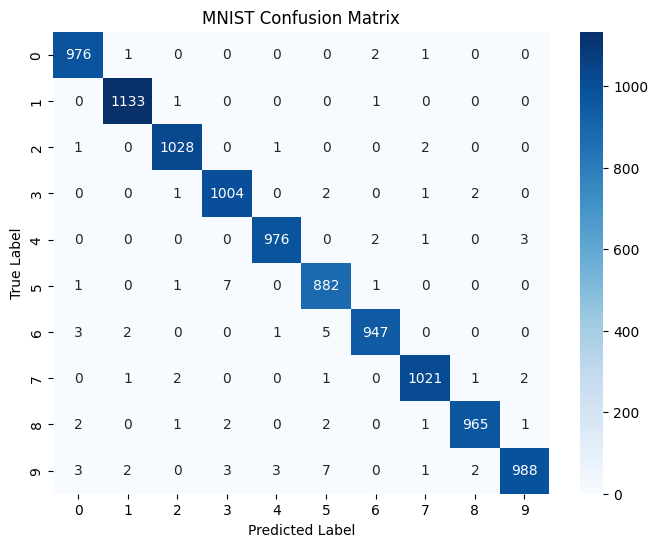

In [ ]:
cm = confusion_matrix(
    y_test,
    predicted_labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("MNIST Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

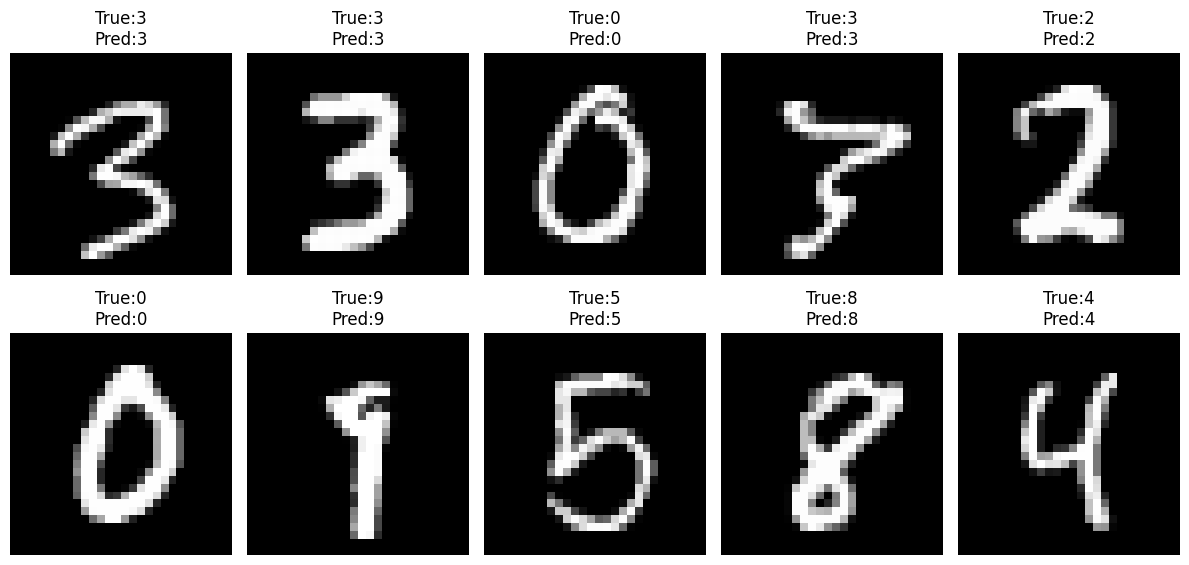

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):

    index = np.random.randint(0, len(X_test))

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[index].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"True:{y_test[index]}\nPred:{predicted_labels[index]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step


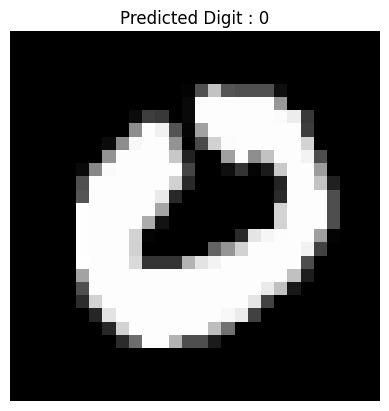

In [ ]:
index = 25

image = X_test[index]

prediction = mnist_model.predict(
    image.reshape(1,28,28,1)
)

predicted_digit = np.argmax(prediction)

plt.imshow(
    image.reshape(28,28),
    cmap='gray'
)

plt.title(f"Predicted Digit : {predicted_digit}")
plt.axis("off")

plt.show()

In [ ]:
mnist_model.save("MNIST_CNN_Model.h5")

print("MNIST model saved successfully.")

MNIST model saved successfully.


In [ ]:
print("="*50)
print("MNIST CNN MODEL SUMMARY")
print("="*50)

print(f"Training Images : {len(X_train)}")
print(f"Testing Images  : {len(X_test)}")
print(f"Number of Classes : 10")

print(f"\nFinal Test Accuracy : {test_accuracy*100:.2f}%")
print("="*50)

MNIST CNN MODEL SUMMARY
Training Images : 60000
Testing Images  : 10000
Number of Classes : 10

Final Test Accuracy : 99.20%


In [ ]:
from google.colab import files
files.upload()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
train_df = pd.read_csv("/content/emnist-letters-train.csv", header=None)
test_df = pd.read_csv("/content/emnist-letters-test.csv", header=None)

print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)

Training Dataset Shape : (88800, 785)
Testing Dataset Shape  : (14800, 785)


In [ ]:
X_train_emnist = train_df.iloc[:, 1:].values
y_train_emnist = train_df.iloc[:, 0].values

X_test_emnist = test_df.iloc[:, 1:].values
y_test_emnist = test_df.iloc[:, 0].values

print("Training Images :", X_train_emnist.shape)
print("Training Labels :", y_train_emnist.shape)

print("Testing Images :", X_test_emnist.shape)
print("Testing Labels :", y_test_emnist.shape)

Training Images : (88800, 784)
Training Labels : (88800,)
Testing Images : (14800, 784)
Testing Labels : (14800,)


In [ ]:
y_train_emnist = y_train_emnist - 1
y_test_emnist = y_test_emnist - 1

In [ ]:
X_train_emnist = X_train_emnist.reshape(-1,28,28)
X_test_emnist = X_test_emnist.reshape(-1,28,28)

In [ ]:
X_train_emnist = np.array(
    [np.fliplr(np.rot90(img)) for img in X_train_emnist]
)

X_test_emnist = np.array(
    [np.fliplr(np.rot90(img)) for img in X_test_emnist]
)

In [ ]:
X_train_emnist = X_train_emnist.astype("float32") / 255.0
X_test_emnist = X_test_emnist.astype("float32") / 255.0

In [ ]:
X_train_emnist = X_train_emnist.reshape(-1,28,28,1)
X_test_emnist = X_test_emnist.reshape(-1,28,28,1)

print(X_train_emnist.shape)
print(X_test_emnist.shape)

(88800, 28, 28, 1)
(14800, 28, 28, 1)


In [ ]:
y_train_emnist_cat = to_categorical(y_train_emnist,26)
y_test_emnist_cat = to_categorical(y_test_emnist,26)

print(y_train_emnist_cat.shape)

(88800, 26)


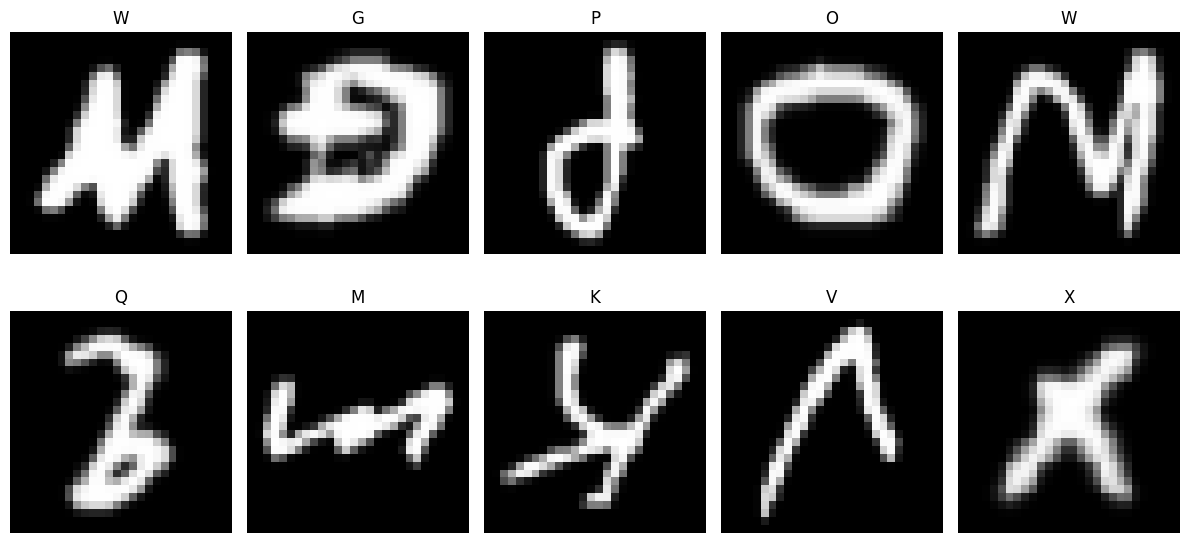

In [ ]:
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_train_emnist[i].reshape(28,28),
        cmap="gray"
    )

    plt.title(
        letters[y_train_emnist[i]]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
emnist_model = Sequential()

emnist_model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    )
)

emnist_model.add(
    MaxPooling2D((2,2))
)

emnist_model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

emnist_model.add(
    MaxPooling2D((2,2))
)

emnist_model.add(
    Flatten()
)

emnist_model.add(
    Dense(
        128,
        activation="relu"
    )
)

emnist_model.add(
    Dropout(0.5)
)

emnist_model.add(
    Dense(
        26,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
emnist_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

emnist_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_emnist = emnist_model.fit(
    X_train_emnist,
    y_train_emnist_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.6641 - loss: 1.0997 - val_accuracy: 0.8768 - val_loss: 0.4027
Epoch 2/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8243 - loss: 0.5548 - val_accuracy: 0.8934 - val_loss: 0.3349
Epoch 3/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8543 - loss: 0.4568 - val_accuracy: 0.9096 - val_loss: 0.2821
Epoch 4/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8699 - loss: 0.4036 - val_accuracy: 0.9178 - val_loss: 0.2583
Epoch 5/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8817 - loss: 0.3657 - val_accuracy: 0.9224 - val_loss: 0.2436
Epoch 6/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8905 - loss: 0.3372 - val_accuracy: 0.9254 - val_loss: 0.2348
Epoch 7/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8972 - loss: 0.3148 - val_accuracy: 0.9288 - val_loss: 0.2236
Epoch 8/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9026 - loss: 0.2956 - val_accuracy: 0.

In [ ]:
test_loss_emnist, test_accuracy_emnist = emnist_model.evaluate(
    X_test_emnist,
    y_test_emnist_cat
)

print("Test Loss :", test_loss_emnist)
print("Test Accuracy :", test_accuracy_emnist)

463/463 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9173 - loss: 0.2384
Test Loss : 0.2384006381034851
Test Accuracy : 0.9172973036766052


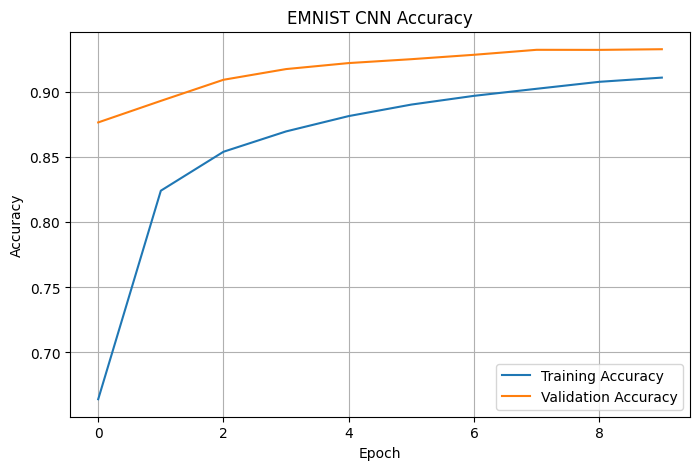

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_emnist.history['accuracy'], label='Training Accuracy')
plt.plot(history_emnist.history['val_accuracy'], label='Validation Accuracy')

plt.title("EMNIST CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

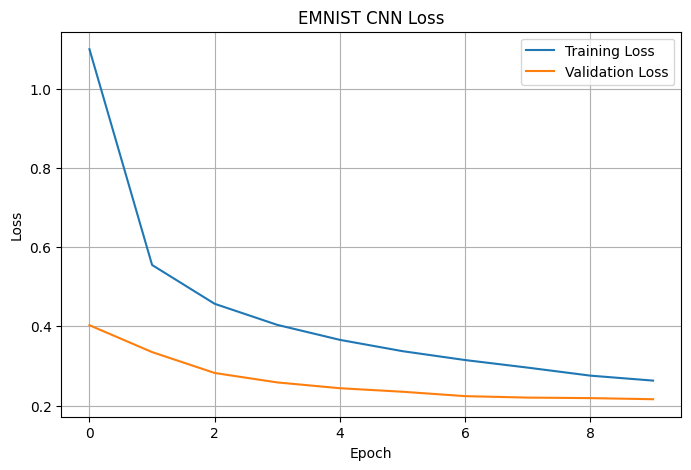

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_emnist.history['loss'], label='Training Loss')
plt.plot(history_emnist.history['val_loss'], label='Validation Loss')

plt.title("EMNIST CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
predictions = emnist_model.predict(X_test_emnist)

predicted_labels = np.argmax(predictions, axis=1)

463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
print("Classification Report\n")

print(
    classification_report(
        y_test_emnist,
        predicted_labels
    )
)

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       800
           1       0.97      0.97      0.97       800
           2       0.94      0.97      0.96       800
           3       0.98      0.90      0.94       800
           4       0.97      0.95      0.96       800
           5       0.99      0.94      0.96       800
           6       0.89      0.77      0.83       800
           7       0.94      0.94      0.94       800
           8       0.76      0.74      0.75       800
           9       0.97      0.93      0.95       800
          10       0.96      0.96      0.96       800
          11       0.74      0.78      0.76       800
          12       0.98      0.99      0.98       800
          13       0.96      0.94      0.95       800
          14       0.92      0.98      0.95       800
          15       0.98      0.98      0.98       800
          16       0.82      0.86      0.84       800
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


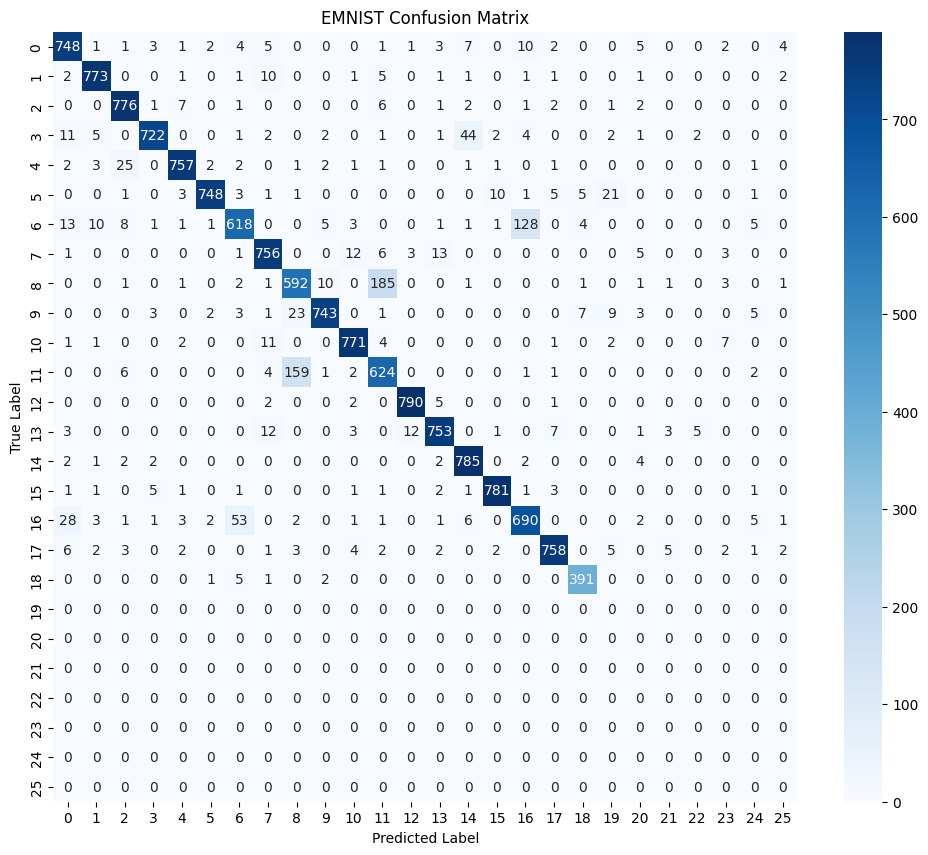

In [ ]:
cm = confusion_matrix(
    y_test_emnist,
    predicted_labels
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("EMNIST Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

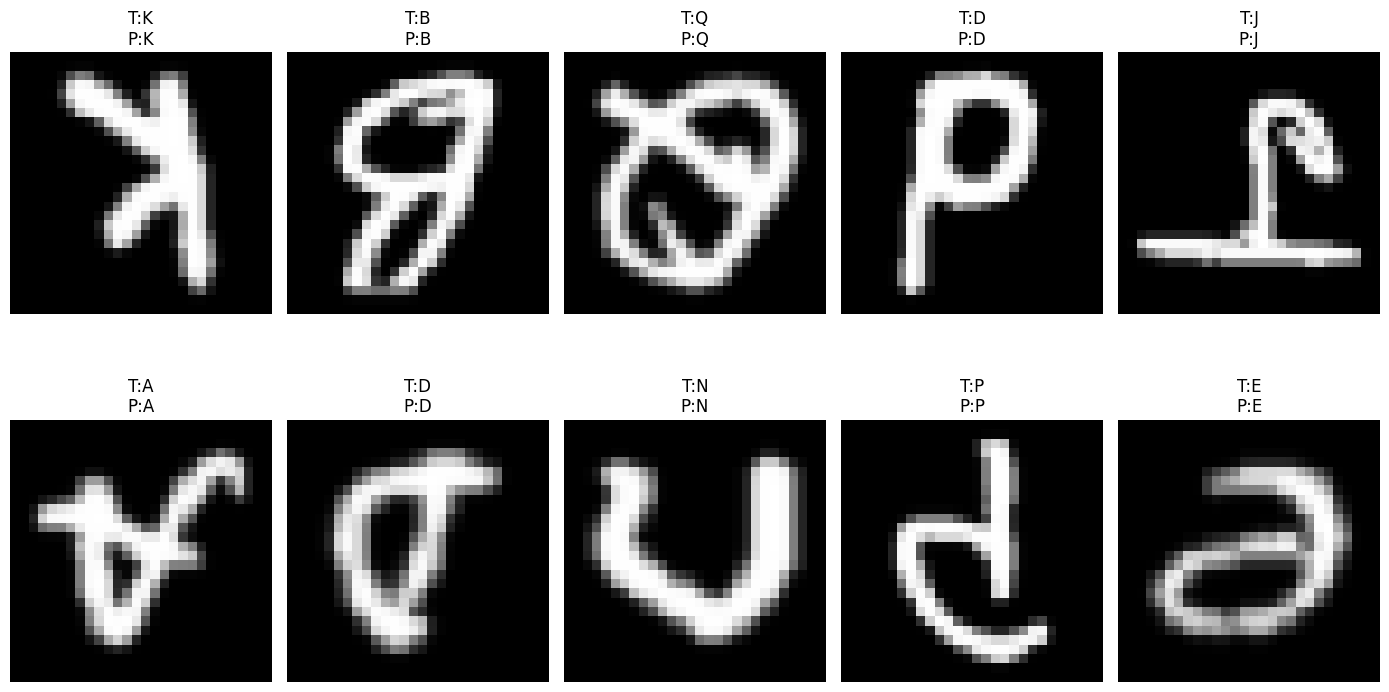

In [ ]:
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

plt.figure(figsize=(14,8))

for i in range(10):

    index = np.random.randint(0, len(X_test_emnist))

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test_emnist[index].reshape(28,28),
        cmap="gray"
    )

    true_letter = letters[y_test_emnist[index]]
    pred_letter = letters[predicted_labels[index]]

    plt.title(f"T:{true_letter}\nP:{pred_letter}")

    plt.axis("off")

plt.tight_layout()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step


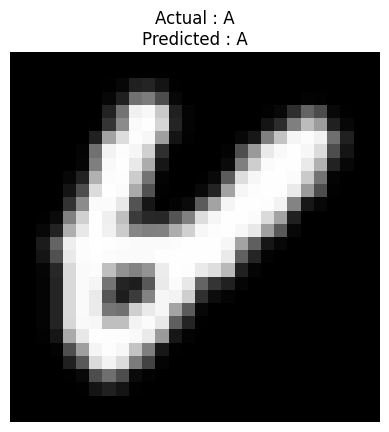

In [ ]:
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

index = 100

image = X_test_emnist[index]

prediction = emnist_model.predict(
    image.reshape(1,28,28,1)
)

predicted_letter = letters[np.argmax(prediction)]

actual_letter = letters[y_test_emnist[index]]

plt.imshow(
    image.reshape(28,28),
    cmap="gray"
)

plt.title(
    f"Actual : {actual_letter}\nPredicted : {predicted_letter}"
)

plt.axis("off")

plt.show()

In [ ]:
emnist_model.save("EMNIST_CNN_Model.h5")

print("EMNIST model saved successfully.")

EMNIST model saved successfully.


In [ ]:
print("="*50)
print("EMNIST CNN MODEL SUMMARY")
print("="*50)

print(f"Training Images : {len(X_train_emnist)}")
print(f"Testing Images  : {len(X_test_emnist)}")
print("Classes         : 26 (A-Z)")
print(f"Test Accuracy   : {test_accuracy_emnist*100:.2f}%")

print("="*50)

EMNIST CNN MODEL SUMMARY
Training Images : 88800
Testing Images  : 14800
Classes         : 26 (A-Z)
Test Accuracy   : 91.73%


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Dataset": ["MNIST", "EMNIST Letters"],
    "Training Images": [60000, len(X_train_emnist)],
    "Testing Images": [10000, len(X_test_emnist)],
    "Classes": [10, 26],
    "Test Accuracy (%)": [
        round(test_accuracy * 100, 2),
        round(test_accuracy_emnist * 100, 2)
    ]
})

comparison

,Dataset,Training Images,Testing Images,Classes,Test Accuracy (%)
0,MNIST,60000,10000,10,99.20
1,EMNIST Letters,88800,14800,26,91.73


In [ ]:
print("FINAL CONCLUSION")
print("-"*60)

print(f"MNIST Test Accuracy  : {test_accuracy*100:.2f}%")
print(f"EMNIST Test Accuracy : {test_accuracy_emnist*100:.2f}%")

if test_accuracy > test_accuracy_emnist:
    print("\nThe CNN achieved higher accuracy on MNIST.")
    print("EMNIST is more challenging because it contains")
    print("26 handwritten letter classes with many similar shapes.")
else:
    print("\nThe CNN performed similarly on both datasets.")

print("\nProject Completed Successfully.")

FINAL CONCLUSION
------------------------------------------------------------
MNIST Test Accuracy  : 99.20%
EMNIST Test Accuracy : 91.73%

The CNN achieved higher accuracy on MNIST.
EMNIST is more challenging because it contains
26 handwritten letter classes with many similar shapes.

Project Completed Successfully.


In [ ]:
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import TimeDistributed

In [ ]:
crnn_model = Sequential()

# CNN Feature Extraction
crnn_model.add(
    Conv2D(32, (3,3),
           activation='relu',
           input_shape=(28,28,1))
)

crnn_model.add(MaxPooling2D((2,2)))

crnn_model.add(
    Conv2D(64,(3,3),
           activation='relu')
)

crnn_model.add(MaxPooling2D((2,2)))

# Convert feature maps to sequence
crnn_model.add(
    Reshape((5,320))
)

# Recurrent Layers
crnn_model.add(
    Bidirectional(
        LSTM(128, return_sequences=True)
    )
)

crnn_model.add(
    Bidirectional(
        LSTM(64)
    )
)

# Fully Connected Layer
crnn_model.add(
    Dense(128, activation='relu')
)

crnn_model.add(
    Dropout(0.5)
)

# Output Layer (26 letters)
crnn_model.add(
    Dense(26, activation='softmax')
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
crnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

crnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 5, 320)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 5, 256)         │       459,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662,810 (2.53 MB)

 Trainable params: 662,810 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_crnn = crnn_model.fit(
    X_train_emnist,
    y_train_emnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7089 - loss: 0.9603 - val_accuracy: 0.9006 - val_loss: 0.3079
Epoch 2/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8982 - loss: 0.3335 - val_accuracy: 0.9178 - val_loss: 0.2516
Epoch 3/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9175 - loss: 0.2580 - val_accuracy: 0.9258 - val_loss: 0.2303
Epoch 4/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9303 - loss: 0.2180 - val_accuracy: 0.9318 - val_loss: 0.2105
Epoch 5/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9363 - loss: 0.1947 - val_accuracy: 0.9283 - val_loss: 0.2231
Epoch 6/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9409 - loss: 0.1769 - val_accuracy: 0.9369 - val_loss: 0.1993
Epoch 7/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9446 - loss: 0.1596 - val_accuracy: 0.9353 - val_loss: 0.2061
Epoch 8/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9500 - loss: 0.1452 - val_acc

In [ ]:
crnn_loss, crnn_accuracy = crnn_model.evaluate(
    X_test_emnist,
    y_test_emnist_cat
)

print("CRNN Accuracy :", crnn_accuracy)

463/463 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9237 - loss: 0.2357
CRNN Accuracy : 0.9237161874771118


In [ ]:
comparison = pd.DataFrame({
    "Model": ["CNN", "CRNN"],
    "Dataset": ["EMNIST", "EMNIST"],
    "Accuracy (%)": [
        round(test_accuracy_emnist*100,2),
        round(crnn_accuracy*100,2)
    ]
})

print(comparison)

  Model Dataset  Accuracy (%)
0   CNN  EMNIST         91.73
1  CRNN  EMNIST         92.37


In [ ]:
crnn_model.save("EMNIST_CRNN_Model.h5")

print("CRNN model saved successfully.")

CRNN model saved successfully.


In [ ]:
print("="*60)
print("FINAL PROJECT SUMMARY")
print("="*60)

print(f"MNIST CNN Accuracy   : {test_accuracy*100:.2f}%")
print(f"EMNIST CNN Accuracy  : {test_accuracy_emnist*100:.2f}%")
print(f"EMNIST CRNN Accuracy : {crnn_accuracy*100:.2f}%")

print("\nThe CNN model effectively recognized handwritten")
print("digits and letters.")

print("\nThe CRNN architecture extends the system by")
print("combining CNN feature extraction with recurrent")
print("layers, making it suitable for future")
print("word and sentence recognition tasks.")

print("\nProject Completed Successfully.")

FINAL PROJECT SUMMARY
MNIST CNN Accuracy   : 99.20%
EMNIST CNN Accuracy  : 91.73%
EMNIST CRNN Accuracy : 92.37%

The CNN model effectively recognized handwritten
digits and letters.

The CRNN architecture extends the system by
combining CNN feature extraction with recurrent
layers, making it suitable for future
word and sentence recognition tasks.

Project Completed Successfully.
